In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_performance.csv to student_performance.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
import os
print(os.listdir())

['.config', 'student_performance.csv', 'sample_data']


In [ ]:
df = pd.read_csv("student_performance.csv")

print("First 5 rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

First 5 rows:
   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score grade  
0                  3.8         97.9     A  
1                  2.5         83.9     B  
2                  5.3        100.0     A  
3                  7.0        100.0     A  
4                  6.9         92.0     A  

Columns:
Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())

# Fill numeric missing values (safe step)
df = df.fillna(df.mean(numeric_only=True))


Missing Values:
 student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("\nAfter Encoding:")
print(df.head())


After Encoding:
   student_id  weekly_self_study_hours  attendance_percentage  \
0           1                     18.5                   95.6   
1           2                     14.0                   80.0   
2           3                     19.5                   86.3   
3           4                     25.7                   70.2   
4           5                     13.4                   81.9   

   class_participation  total_score  grade  
0                  3.8         97.9      0  
1                  2.5         83.9      1  
2                  5.3        100.0      0  
3                  7.0        100.0      0  
4                  6.9         92.0      0  


In [ ]:
print(df.columns)

Index(['student_id', 'weekly_self_study_hours', 'attendance_percentage',
       'class_participation', 'total_score', 'grade'],
      dtype='object')


In [ ]:
target_column = "total_score"

# Drop student_id (not useful for prediction)
X = df.drop([target_column, "student_id"], axis=1)
y = df[target_column]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n===== MODEL PERFORMANCE =====")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)


===== MODEL PERFORMANCE =====
MAE  : 3.3843680207292706
MSE  : 16.572427957941972
RMSE : 4.070924705511264
R2 Score : 0.9303897717321341


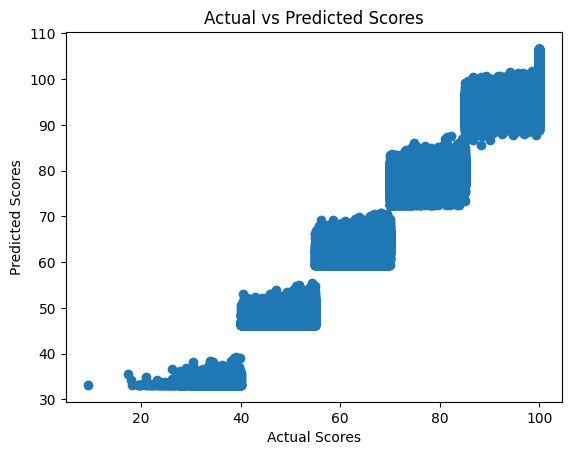

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.show()

In [ ]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Importance:\n", coefficients)


Feature Importance:
                          Coefficient
weekly_self_study_hours     0.525415
attendance_percentage       0.000290
class_participation        -0.000960
grade                     -13.104395
